# Homework06

Exercises to practice pandas, data analysis and regression

## Goals

- Understand the effects of pre-processing data
- Get familiar with the ML flow: encode -> normalize -> train -> evaluate
- Understand the difference between regression and classification tasks
- Build intuition for different regression models

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor

from data_utils import object_from_json_url
from data_utils import regression_error

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/DM-GY-9103-2024F-H/WK02).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [3]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

[{'age': 18,
  'gender': 'F',
  'height': 66,
  'weight': 135,
  'span': 1699,
  'stature': 1645,
  'ear': {'breadth': 30, 'length': 61, 'protrusion': 20},
  'foot': {'breadth': 97, 'length': 243},
  'hand': {'breadth': 78, 'length': 182, 'palm': 108},
  'head': {'height': 243, 'circumference': 557}},
 {'age': 30,
  'gender': 'M',
  'height': 68,
  'weight': 207,
  'span': 1749,
  'stature': 1715,
  'ear': {'breadth': 35, 'length': 63, 'protrusion': 17},
  'foot': {'breadth': 100, 'length': 252},
  'hand': {'breadth': 87, 'length': 184, 'palm': 114},
  'head': {'height': 238, 'circumference': 560}}]

#### Nested data

This is that *nested* dataset from Week 02.

# 🤔

Let's load it into a `DataFrame` to see what happens.

In [4]:
# Read into DataFrame
ansur_df = pd.DataFrame.from_records(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear,foot,hand,head
0,18,F,66,135,1699,1645,"{'breadth': 30, 'length': 61, 'protrusion': 20}","{'breadth': 97, 'length': 243}","{'breadth': 78, 'length': 182, 'palm': 108}","{'height': 243, 'circumference': 557}"
1,30,M,68,207,1749,1715,"{'breadth': 35, 'length': 63, 'protrusion': 17}","{'breadth': 100, 'length': 252}","{'breadth': 87, 'length': 184, 'palm': 114}","{'height': 238, 'circumference': 560}"
2,27,M,67,121,1684,1657,"{'breadth': 36, 'length': 59, 'protrusion': 24}","{'breadth': 92, 'length': 251}","{'breadth': 84, 'length': 180, 'palm': 103}","{'height': 239, 'circumference': 516}"
3,20,M,73,185,1878,1828,"{'breadth': 36, 'length': 60, 'protrusion': 21}","{'breadth': 104, 'length': 280}","{'breadth': 95, 'length': 201, 'palm': 124}","{'height': 270, 'circumference': 582}"
4,33,M,76,150,1977,1883,"{'breadth': 39, 'length': 65, 'protrusion': 27}","{'breadth': 101, 'length': 271}","{'breadth': 90, 'length': 194, 'palm': 113}","{'height': 254, 'circumference': 559}"



# 😓🙄

That didn't work too well. We ended up with objects in our columns.

Luckily, our `DataFrame` library has a function called [`json_normalize()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.json_normalize.html) that can help.

In [5]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,F,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,M,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,M,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,M,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,M,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559


Much better. `DataFrames` are magic.

#### Data Exploration

Before we start creating models, let's do a little bit of data analysis and get a feeling for the shapes, distributions and relationships of our data.

1. Print `min`, `max` and `average` values for all of the features.
2. Print `covariance` tables for `age`, `ear.length` and `head.circumference`.
3. Plot `age`, `ear.length` and `head.circumference` versus the $1$ *feature* that is most correlated to each of them.

Don't forget to *encode* and *normalize* the data.

                       min     max          avg
age                   17.0    58.0    29.745357
gender                 0.0     1.0     0.672679
height                56.0    94.0    68.247321
weight                 0.0   321.0   174.558393
span                1323.0  2121.0  1763.703393
stature             1409.0  1993.0  1714.265357
ear.breadth           25.0    46.0    35.128929
ear.length            46.0    81.0    62.637143
ear.protrusion        13.0    34.0    22.266786
foot.breadth          77.0   126.0    98.850893
foot.length          198.0   323.0   262.991964
hand.breadth          67.0   105.0    84.936964
hand.length          145.0   239.0   189.260179
hand.palm             88.0   140.0   113.919643
head.height          206.0   295.0   249.170893
head.circumference   502.0   635.0   570.062857
Covariances for ear.length:
ear.length            1.000179
weight                0.487481
hand.breadth          0.465829
gender                0.463540
ear.breadth           0.454968
s

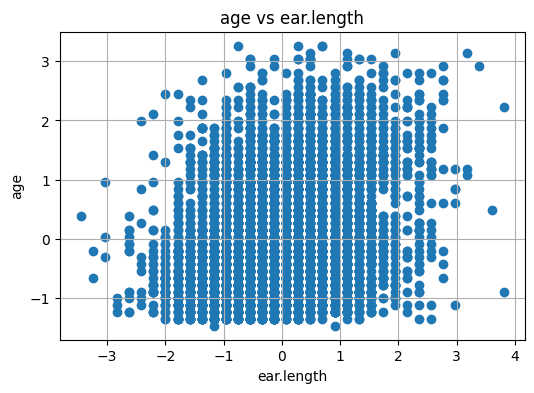

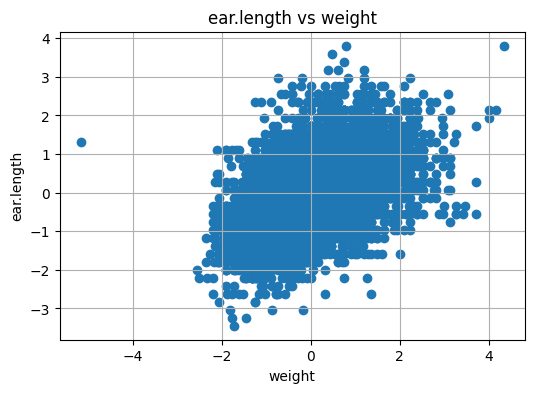

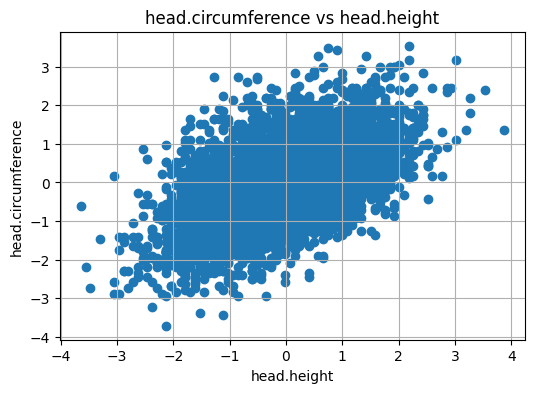

In [14]:
# Work on Data Exploration here

### Encode non-numerical features
ansur_encoded_df = ansur_df.copy()


ansur_encoded_df["gender"] = ansur_encoded_df["gender"].replace({
    "M": "Male",
    "F": "Female"
})

# Encode non-numerical features
ansur_encoder = OrdinalEncoder()
ansur_encoded_df[["gender"]] = ansur_encoder.fit_transform(ansur_encoded_df[["gender"]])

# 1. Print min, max, avg
summary_df = pd.DataFrame({
    "min": ansur_encoded_df.min(),
    "max": ansur_encoded_df.max(),
    "avg": ansur_encoded_df.mean()
})
print(summary_df)

# Normalize all data
ansur_scaler = StandardScaler()
ansur_df_normalize = pd.DataFrame(
    ansur_scaler.fit_transform(ansur_encoded_df),
    columns=ansur_encoded_df.columns
)

# 2. Print covariance tables
# print("Covariances for age:")
# print(ansur_df_normalize.cov()["age"].sort_values(ascending=False))
# print()

print("Covariances for ear.length:")
print(ansur_df_normalize.cov()["ear.length"].sort_values(ascending=False))
print()

# print("Covariances for head.circumference:")
# print(ansur_df_normalize.cov()["head.circumference"].sort_values(ascending=False))
# print()

## 3. Plot features most correlated to age, ear length and head circumference
cov_matrix = ansur_df_normalize.cov()

age_partner = cov_matrix["age"].drop("age").abs().idxmax()
ear_partner = cov_matrix["ear.length"].drop("ear.length").abs().idxmax()
head_partner = cov_matrix["head.circumference"].drop("head.circumference").abs().idxmax()

weight_partner = cov_matrix["weight"].drop("weight").abs().idxmax()

print(weight_partner)


# print("Most correlated with age:", age_partner)
print("Most correlated with ear.length:", ear_partner)
# print("Most correlated with head.circumference:", head_partner)

plt.figure(figsize=(6, 4))
plt.scatter(ansur_df_normalize[age_partner], ansur_df_normalize["age"])
plt.xlabel(age_partner)
plt.ylabel("age")
plt.title(f"age vs {age_partner}")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(ansur_df_normalize[ear_partner], ansur_df_normalize["ear.length"])
plt.xlabel(ear_partner)
plt.ylabel("ear.length")
plt.title(f"ear.length vs {ear_partner}")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(ansur_df_normalize[head_partner], ansur_df_normalize["head.circumference"])
plt.xlabel(head_partner)
plt.ylabel("head.circumference")
plt.title(f"head.circumference vs {head_partner}")
plt.grid(True)
plt.show()




### Interpretation

<span style="color:hotpink;">
Does anything stand out about these graphs? Or the correlations?<br>
Are correlations symmetric? Does the feature most correlated to ear length also have ear length as its most correlated pair?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER. Age there is very little linear relation. Ear length is is more of a linear relation and finally head circumference there is a linear relation.  Head circumference does have a symmetric correlation. The faeture most correlated to ear length does not have ear lenhth as its most correlated pair.</span>

### Regression

Now, we want to create a regression model to predict `head.circumference` from the data.

From our [Week 06](https://github.com/PSAM-5020-2026S-A/WK06) notebook, we can create a regression model by following these steps:

1. Load dataset (done! 🎉)
2. Encode label features as numbers (done! ⚡️)
3. Normalize the data (done! 🍾)
4. Separate the outcome variable and the input features
5. Create a regression model using all features
6. Run model on training data and measure error
7. Plot predictions and interpret results
8. Run model on test data, measure error, plot predictions, interpret results

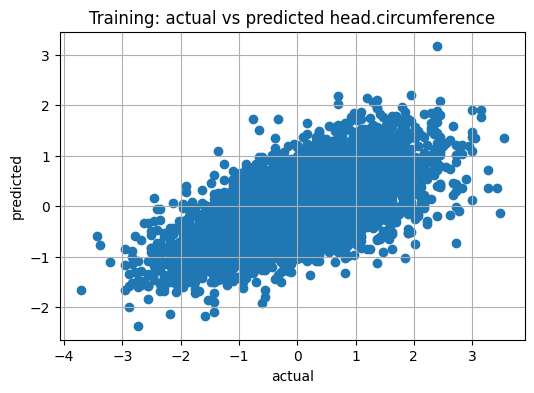

In [7]:
# Work on Regression Model here
## Separate outcome variable and input features

X_train = ansur_df_normalize.drop(columns=["head.circumference"])
y_train = ansur_df_normalize["head.circumference"]

# Create regression model
head_circumference_regMod = LinearRegression()
head_circumference_regMod.fit(X_train, y_train)

# Measure error on training data
train_predictions = head_circumference_regMod.predict(X_train)
regression_error(y_train, train_predictions)

# Plot predictions and interpret results
plt.figure(figsize=(6, 4))
plt.scatter(y_train, train_predictions)
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("Training: actual vs predicted head.circumference")
plt.grid(True)
plt.show()

In [8]:
## Load Test Data
ANSUR_TEST_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur-test.json"

ansur_test_data = object_from_json_url(ANSUR_TEST_FILE)
ansur_test_df = pd.json_normalize(ansur_test_data)

ansur_test_encoded_df = ansur_test_df.copy()

ansur_test_encoded_df["gender"] = ansur_test_encoded_df["gender"].replace({
    "M": "Male",
    "F": "Female"
})

ansur_test_encoded_df[["gender"]] = ansur_encoder.transform(
    ansur_test_encoded_df[["gender"]]
)

ansur_test_scaled_df = pd.DataFrame(
    ansur_scaler.transform(ansur_test_encoded_df),
    columns=ansur_test_encoded_df.columns
)

ansur_test_scaled_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,-1.125304,0.697563,0.452954,-0.727781,-0.123494,0.263447,0.270940,0.489559,-0.716543,0.022439,-0.056985,0.324677,0.499217,-0.128919,0.491695,-0.821259
1,1.068641,-1.433562,-1.356093,-1.113032,-0.988637,-1.457006,-0.973228,-0.132009,-1.664859,-1.030966,-0.803796,-1.091728,-0.283552,-0.269102,-0.183119,-0.821259
2,-0.778892,0.697563,-0.322352,-0.727781,0.318090,0.119151,1.515107,0.075180,-0.716543,-0.429021,0.689826,0.796812,1.108038,1.132731,0.744751,-0.166993
3,0.260345,0.697563,0.194519,0.161260,0.354138,0.174650,-1.284270,0.489559,0.547878,0.473898,0.115356,0.324677,0.238294,0.431814,-0.436174,0.868927
4,-1.125304,0.697563,1.486695,-0.135087,1.111138,1.195822,0.581982,0.903938,2.760615,0.925357,0.804720,-0.147458,0.760141,0.992547,-1.364043,-0.766737


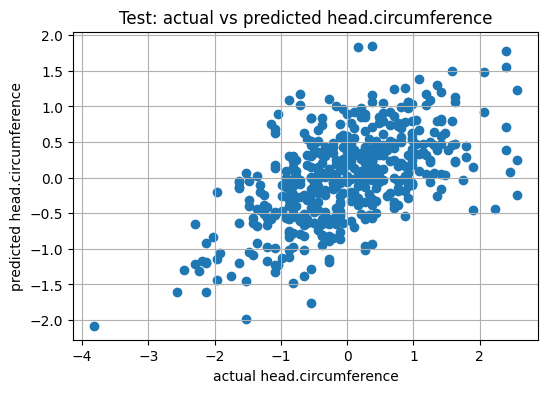

0.7891115826821988


In [10]:
## Run model on test data

X_test = ansur_test_scaled_df.drop(columns=["head.circumference"])
y_test = ansur_test_scaled_df["head.circumference"]

test_predictions = head_circumference_regMod.predict(X_test)

# Measure error on test data
regression_error(y_test, test_predictions)

# Plot predictions and interpret results
plt.figure(figsize=(6, 4))
plt.scatter(y_test, test_predictions)
plt.xlabel("actual head.circumference")
plt.ylabel("predicted head.circumference")
plt.title("Test: actual vs predicted head.circumference")
plt.grid(True)
plt.show()

print(regression_error(y_test, test_predictions))

### Interpretation

<span style="color:hotpink;">
How well does your model perform?<br>
How could you improve it?<br>
Are there ranges of circumferences that don't get predicted well?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER
General trend is good. Hovering around 0 which means you see a linear relation os the model is learnign something.YOu see ouitliers. You could clean the data to train the data. Collect more data check for outliers. Maybe check for a skinny head and the circumference is small (a cylindrical shape) that is an outlier. Removing the outliers might help. Having more features would help improve it too.</span>